# Sampling synthetic observations for data assimilation

We build a **twin (OSSE) experiment** for the 2D QG model, in the correct order:

1. **Measure the error-doubling time** of *this* regime from two nearly identical
   long runs. This is a property of the settings (`nu`, `mu`, `A`, `k_f`, ...),
   so it must be measured, not assumed.
2. **Set the clock** from that measurement: fix the doubling time to the
   atmosphere's (~2 days) and read off what "6 hours" is in model time units.
3. **Run two long trajectories** — a *control* (undisturbed) and a *truth*
   (disturbed) — and **sample observations** from the truth at the 6-hour
   cadence, with 100 % and 25 % spatial coverage.
4. **Sanity checks**: divergence, snapshots, coverage, noise statistics, spectra.

Observations from the disturbed *truth* will later be assimilated into the
undisturbed *control*.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline

from QG_2D import QG2D, _save_netcdf
from visualization import kinetic_energy_spectrum

os.makedirs("da_data", exist_ok=True)
seed = 42

def show(ax, field, L, cmap="RdBu_r", vsym=None, title=None):
    """imshow a [x, y]-indexed field with x horizontal, y vertical."""
    if vsym is None:
        vsym = np.nanmax(np.abs(field))
    im = ax.imshow(field.T, cmap=cmap, origin="lower", extent=[0, L, 0, L],
                   vmin=-vsym, vmax=vsym)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    if title:
        ax.set_title(title)
    return im

## Parameters

A clearly chaotic regime (the repo default). The observation cadence
`OBS_EVERY` is **not set here** — it is derived in Part 2 from the doubling time
measured in Part 1.

In [2]:
PARAMS = dict(N=64, beta=0.0, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4)
dt = 0.01                      # integration step (MTU) 

# --- doubling-time estimation (Part 1) ---
SPINUP_EST = 50.0              # spin-up onto the attractor before launching pairs
T_EST      = 15.0              # length of each twin run (MTU)
N_PAIRS    = 5                 # independent twin pairs, averaged for robustness
EPS_FRAC   = 1e-4              # initial perturbation size, fraction of clim vorticity

# --- observation sampling (Part 3-4) ---
N_CYCLES    = 2400            # number of observation times (raise for a larger
                              #   ML-training dataset, e.g. 2400)
SPINUP_OBS  = 40.0            # spin-up before the sampling window
PERT_FRAC   = 0.05            # initial truth-control difference (fraction of clim)
NOISE_FRAC  = 0.10            # observation error std (fraction of clim)
SPARSE_FRAC = 0.25            # sparse coverage

## Part 1 — Measure the error-doubling time

**Idea.** Start two copies of the flow that are *almost* identical (they differ
by a tiny perturbation). Because the system is chaotic, the difference between
them grows exponentially:

$$\text{RMSE}(t) \approx \text{RMSE}(0)\, e^{\lambda_1 t},$$

where $\lambda_1$ is the leading Lyapunov exponent. On a log axis this is a
straight line whose slope is $\lambda_1$. The **error-doubling time** is then

$$\tau_2 = \frac{\ln 2}{\lambda_1}.$$

To get a reliable number we launch several twin pairs from different points
along one long run and average the slope. The perturbation is a *smooth*
(band-limited) field so it excites only resolved scales — not the grid-scale
modes the hyperviscosity immediately kills.

In [3]:
def estimate_doubling_time(params, dt, spinup, T, n_pairs, eps_frac, seed):
    m = QG2D(**params)
    qh = np.fft.fft2(m.random_ic(seed=seed, amp=2.0))
    for _ in range(int(round(spinup / dt))):        # long spin-up to the attractor
        qh = m.step(qh, dt)
    clim = np.real(np.fft.ifft2(qh)).std()

    nsteps = int(round(T / dt))
    rmse_pairs, lams = [], []
    for j in range(n_pairs):
        for _ in range(int(round(3.0 / dt))):       # move to a new attractor point
            qh = m.step(qh, dt)
        base = np.real(np.fft.ifft2(qh))
        d = m.random_ic(seed=seed + 1000 + j, amp=1.0)   # smooth perturbation
        d *= eps_frac * clim / d.std()
        qa, qc = np.fft.fft2(base), np.fft.fft2(base + d)

        ts, rs = [], []
        for i in range(nsteps):
            if i % 5 == 0:
                A = np.real(np.fft.ifft2(qa)); C = np.real(np.fft.ifft2(qc))
                ts.append(i * dt); rs.append(np.sqrt(np.mean((A - C) ** 2)))
            qa, qc = m.step(qa, dt), m.step(qc, dt)
        ts, rs = np.array(ts), np.array(rs)

        lo, hi = 3 * eps_frac * clim, 0.15 * clim   # fit the clean exponential band
        mk = (rs > lo) & (rs < hi)
        slope = np.polyfit(ts[mk], np.log(rs[mk]), 1)[0]
        lams.append(slope); rmse_pairs.append(rs)
    return ts, np.array(rmse_pairs), np.array(lams), clim


cache = "da_data/doubling_time.npz"
if os.path.exists(cache):
    z = np.load(cache)
    ts, rmse_pairs, lams, clim_est = z["ts"], z["rmse_pairs"], z["lams"], float(z["clim"])
else:
    ts, rmse_pairs, lams, clim_est = estimate_doubling_time(
        PARAMS, dt, SPINUP_EST, T_EST, N_PAIRS, EPS_FRAC, seed)
    np.savez(cache, ts=ts, rmse_pairs=rmse_pairs, lams=lams, clim=clim_est)

lam1   = lams.mean()
lam_sd = lams.std()
tau2_pairs = np.log(2) / lams
tau2   = tau2_pairs.mean()
tau2_sd = tau2_pairs.std()
print(f"leading Lyapunov exponent  lambda_1 = {lam1:.3f} +/- {lam_sd:.3f}  MTU^-1")
print(f"error-doubling time        tau_2    = {tau2:.2f} +/- {tau2_sd:.2f}  MTU")

leading Lyapunov exponent  lambda_1 = 0.375 +/- 0.057  MTU^-1
error-doubling time        tau_2    = 1.91 +/- 0.37  MTU


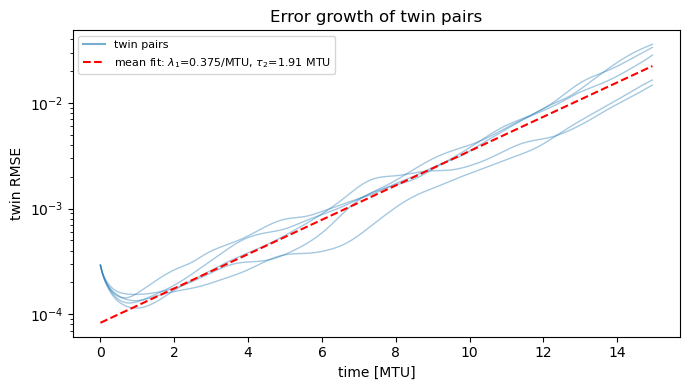

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for rs in rmse_pairs:
    ax.semilogy(ts, rs, color="C0", alpha=0.4, lw=1)
ax.semilogy([], [], color="C0", alpha=0.6, label="twin pairs")
tfit = np.linspace(ts[0], ts[-1], 50)
anchor = np.median([rs[len(ts)//6] for rs in rmse_pairs])
ax.semilogy(tfit, anchor * np.exp(lam1 * (tfit - ts[len(ts)//6])), "r--",
            label=rf"mean fit: $\lambda_1$={lam1:.3f}/MTU, $	\tau_2$={tau2:.2f} MTU")
ax.set_xlabel("time [MTU]"); ax.set_ylabel("twin RMSE")
ax.set_title("Error growth of twin pairs"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Part 2 — Synchronise the clock

The model measures time in model time units (MTU); we need to know how many real
hours one MTU is. We anchor it to the atmosphere, whose small forecast errors
**double in about 2 days** (Lorenz 1969; modern ECMWF ~1.5 days). Setting our
measured $\tau_2 \equiv 2$ days fixes the conversion:

$$ 2\ \text{day} \sim \tau_2\ \text{MTU} \Rightarrow 1\ \text{day} \sim \frac{\tau_2}{2} \ \text{MTU}, \qquad
  \Delta t_\text{obs} = 6\ \text{h} = \tfrac{1}{4}\,\text{day} \sim \frac{\tau_2}{8} \ \text{MTU}.$$

Then `OBS_EVERY = round(dt_obs / dt)` is the number of integration steps between
observations. (We want to assimilate every 6h of 'real time').

In [5]:
DOUBLING_DAYS = 2.0                      # atmospheric anchor
mtu_per_day = tau2 / DOUBLING_DAYS
dt_obs_target = 0.25 * mtu_per_day       # 6 hours in MTU
OBS_EVERY = int(round(dt_obs_target / dt))
DT_OBS = OBS_EVERY * dt
WINDOW = N_CYCLES * DT_OBS

print(f"calibration: tau_2 = {tau2:.2f} MTU := {DOUBLING_DAYS:.0f} days")
print(f"  1 day        = {mtu_per_day:.2f} MTU")
print(f"  6 h (target) = {dt_obs_target:.3f} MTU")
print(f"  OBS_EVERY    = {OBS_EVERY} steps  ->  dt_obs = {DT_OBS:.2f} MTU "
      f"(= {DT_OBS/dt_obs_target:.2f} x 6 h)")
print(f"  window       = {WINDOW:.1f} MTU (~{WINDOW/mtu_per_day:.0f} days), "
      f"{N_CYCLES} observation times")

calibration: tau_2 = 1.91 MTU := 2 days
  1 day        = 0.95 MTU
  6 h (target) = 0.238 MTU
  OBS_EVERY    = 24 steps  ->  dt_obs = 0.24 MTU (= 1.01 x 6 h)
  window       = 576.0 MTU (~604 days), 2400 observation times


## Part 3 — Two long trajectories (control = undisturbed, truth = disturbed)

Both start from one spun-up state, so they are initially *similar*; the truth
gets a small **smooth** perturbation (5 % of climatology) and chaos pulls them
apart. Cached under `da_data/`.

In [6]:
truth_path, ctrl_path = "da_data/truth.nc", "da_data/control.nc"

if os.path.exists(truth_path) and os.path.exists(ctrl_path):
    truth   = QG2D.load(truth_path)
    control = QG2D.load(ctrl_path)
else:
    m = QG2D(**PARAMS)
    qh = np.fft.fft2(m.random_ic(seed=seed, amp=2.0))
    for _ in range(int(round(SPINUP_OBS / dt))):       # shared spin-up
        qh = m.step(qh, dt)
    q_spin = np.real(np.fft.ifft2(qh))

    clim = q_spin.std()
    delta = m.random_ic(seed=seed + 7, amp=1.0)        # smooth perturbation
    delta *= (PERT_FRAC * clim) / delta.std()

    control = m.run(q_spin,         tf=WINDOW, dt=dt, spinup=0.0,
                    store_every=OBS_EVERY, path=ctrl_path)
    truth   = m.run(q_spin + delta, tf=WINDOW, dt=dt, spinup=0.0,
                    store_every=OBS_EVERY, path=truth_path)

times = truth["time"].values
L     = float(truth.attrs["L"])
clim  = float(truth["q"].std())
sigma_obs = NOISE_FRAC * clim
print(f"stored {truth.sizes['time']} snapshots per run at dt_obs={DT_OBS:.2f} MTU")
print(f"climatological vorticity std = {clim:.3f},  sigma_obs = {sigma_obs:.3f}")

stored 2401 snapshots per run at dt_obs=0.24 MTU
climatological vorticity std = 3.261,  sigma_obs = 0.326


## Check 1 — divergence over the sampling window

The two runs should separate exponentially at the rate measured in Part 1, then
saturate near the climatological difference. Zoomed to the early window.

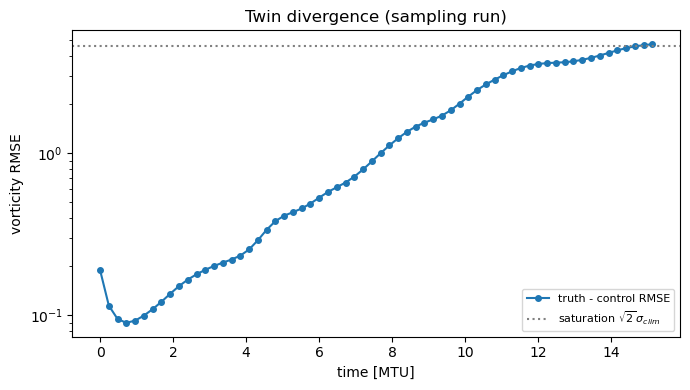

In [7]:
diff = truth["q"].values - control["q"].values
rmse = np.sqrt((diff ** 2).mean(axis=(1, 2)))
sat  = np.sqrt(2) * clim

share = min(1.0, 8 * tau2 / WINDOW)          # show ~8 doubling times
n = max(5, int(round(share * len(times))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(times[:n], rmse[:n], "o-", ms=4, label="truth - control RMSE")
ax.axhline(sat, color="gray", ls=":", label=r"saturation $\sqrt{2}\,\sigma_{clim}$")
ax.set_xlabel("time [MTU]"); ax.set_ylabel("vorticity RMSE")
ax.set_title("Twin divergence (sampling run)"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Check 2 — snapshot comparison

Nearly identical early, fully different once saturated.

t = 5.0 MTU (~5.2 days) -> index 21


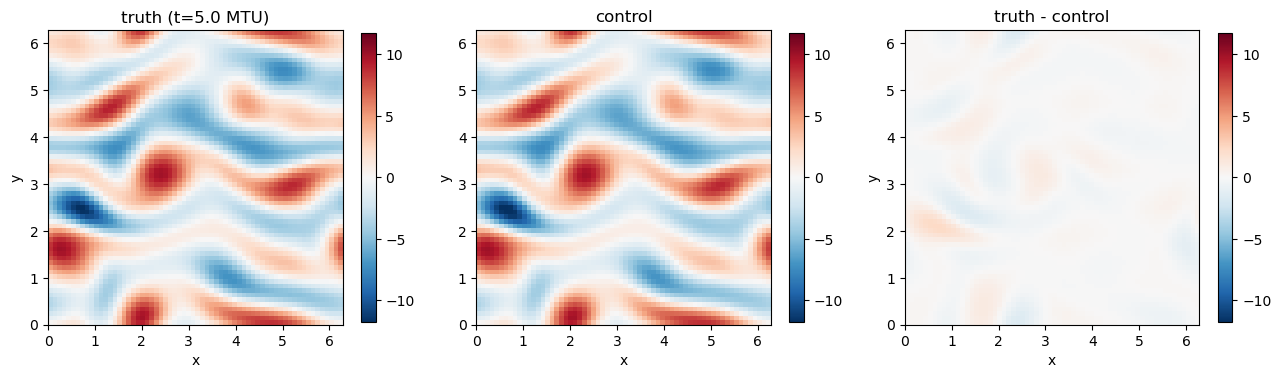

t = 10.0 MTU (~10.5 days) -> index 42


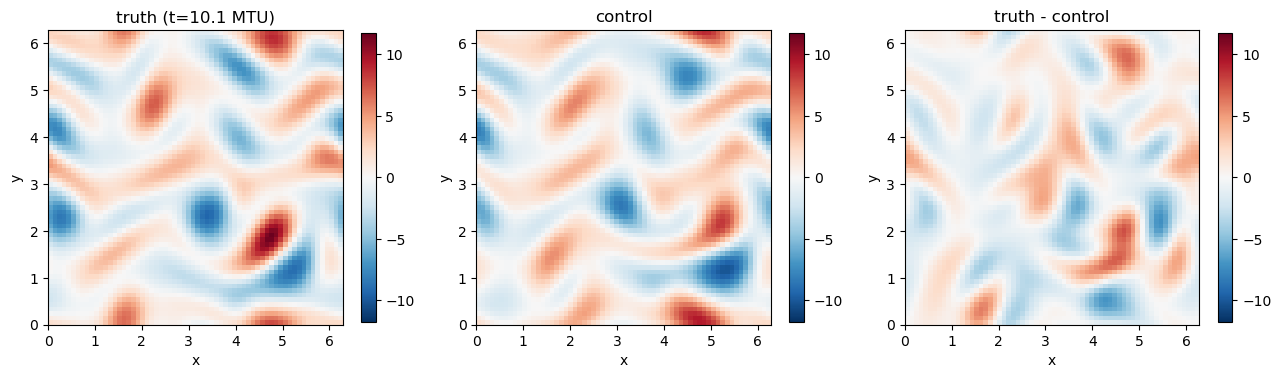

t = 20.0 MTU (~21.0 days) -> index 83


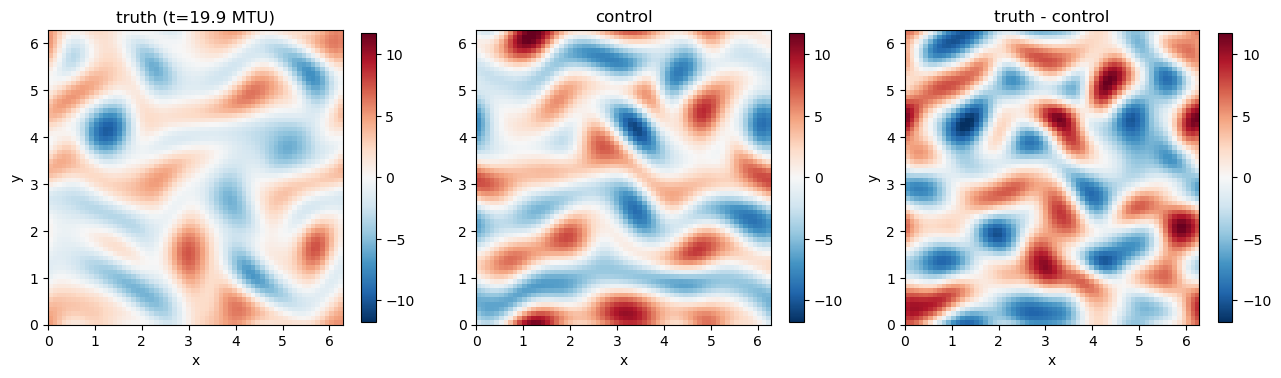

t = 30.0 MTU (~31.5 days) -> index 125


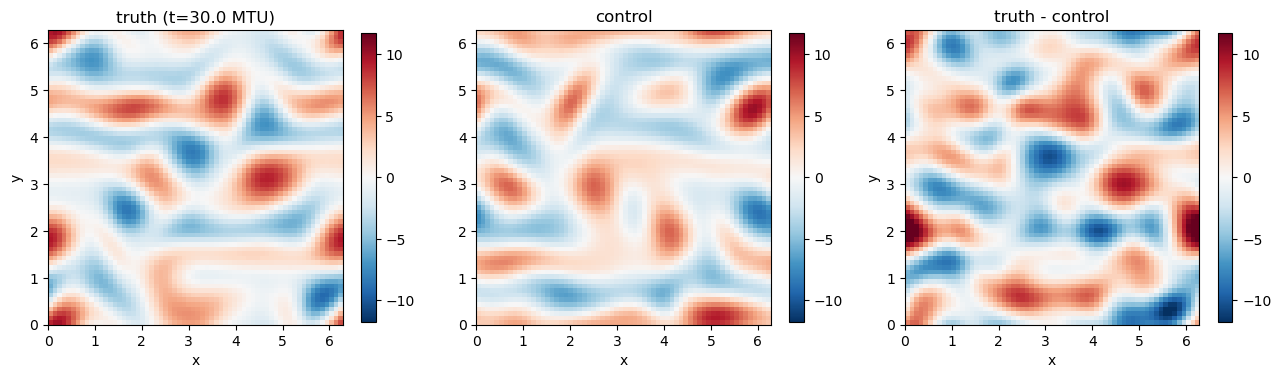

In [8]:
want = [t for t in [5, 10, 20, 30] if t <= times[-1]]
idx = [int(round(t / DT_OBS)) for t in want]
v = np.abs(truth["q"].isel(time=idx[0]).values).max()

for t, ti in zip(want, idx):
    qt = truth["q"].isel(time=ti).values
    qc = control["q"].isel(time=ti).values
    print(f"t = {t:.1f} MTU (~{t/mtu_per_day:.1f} days) -> index {ti}")
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    show(ax[0], qt, L, vsym=v, title=f"truth (t={times[ti]:.1f} MTU)")
    show(ax[1], qc, L, vsym=v, title="control")
    show(ax[2], qt - qc, L, vsym=v, title="truth - control")
    for a in ax:
        fig.colorbar(a.images[0], ax=a, shrink=0.8)
    fig.tight_layout(); plt.show()

## Part 4 — Sample observations (100 % and 25 %)

Observations are the truth plus zero-mean Gaussian noise
($\sigma_\text{obs}=10\%$ of climatology) at every observation time. The **full**
network observes all points; the **sparse** network observes a fixed random 25 %.
Unobserved points are stored as `NaN`, with the coverage mask alongside.

In [9]:
rng = np.random.default_rng(seed)
qtruth = truth["q"].values
N = PARAMS["N"]

mask_full = np.ones((N, N), dtype=bool)
k = int(round(SPARSE_FRAC * N * N))
sel = rng.choice(N * N, size=k, replace=False)
mask_sparse = np.zeros(N * N, dtype=bool); mask_sparse[sel] = True
mask_sparse = mask_sparse.reshape(N, N)

def sample_and_store(mask, coverage, path):
    obs = qtruth + rng.normal(0.0, sigma_obs, size=qtruth.shape)
    obs = np.where(mask[None, :, :], obs, np.nan)
    ds = xr.Dataset(
        {"obs":  (("time", "y", "x"), obs.astype(np.float64)),
         "mask": (("y", "x"), mask.astype(np.int8))},
        coords={"time": times, "y": truth["y"].values, "x": truth["x"].values},
        attrs={**truth.attrs, "sigma_obs": sigma_obs, "dt_obs": DT_OBS,
               "coverage": coverage, "tau2_mtu": tau2, "mtu_per_day": mtu_per_day},
    )
    _save_netcdf(ds, path)
    return ds

obs_full   = sample_and_store(mask_full,   1.0,         "da_data/obs_full.nc")
obs_sparse = sample_and_store(mask_sparse, SPARSE_FRAC, "da_data/obs_sparse.nc")
print("full   coverage:", float(np.isfinite(obs_full["obs"].isel(time=0)).mean()))
print("sparse coverage:", float(np.isfinite(obs_sparse["obs"].isel(time=0)).mean()))

full   coverage: 1.0
sparse coverage: 0.25


## Check 3 — coverage maps and an observed field

Data assimilation only ever sees the right-hand panel.

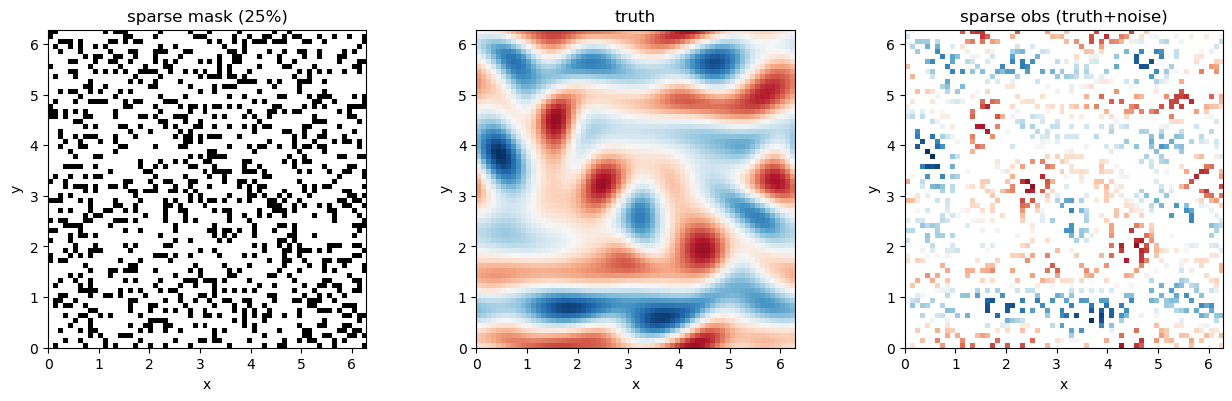

In [10]:
ti = len(times) // 2
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(mask_sparse.T, origin="lower", extent=[0, L, 0, L], cmap="Greys")
ax[0].set_title(f"sparse mask ({SPARSE_FRAC:.0%})"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
v = np.abs(truth["q"].isel(time=ti).values).max()
show(ax[1], truth["q"].isel(time=ti).values, L, vsym=v, title="truth")
show(ax[2], obs_sparse["obs"].isel(time=ti).values, L, vsym=v, title="sparse obs (truth+noise)")
fig.tight_layout(); plt.show()

## Check 4 — observation error statistics

The increments $o - q_\text{truth}$ should be zero-mean Gaussian with
$\sigma_\text{obs}$.

residual mean = -0.0002  (target 0)
residual std  = 0.3261   (target 0.3261)


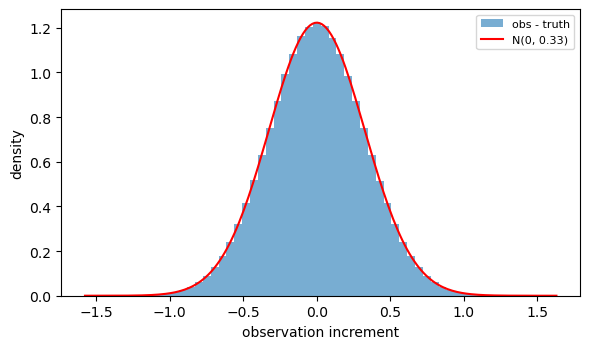

In [11]:
resid = (obs_sparse["obs"].values - qtruth)
resid = resid[np.isfinite(resid)]
print(f"residual mean = {resid.mean():+.4f}  (target 0)")
print(f"residual std  = {resid.std():.4f}   (target {sigma_obs:.4f})")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(resid, bins=60, density=True, alpha=0.6, label="obs - truth")
xx = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xx, np.exp(-xx**2/(2*sigma_obs**2))/(sigma_obs*np.sqrt(2*np.pi)),
        "r-", label=f"N(0, {sigma_obs:.2f})")
ax.set_xlabel("observation increment"); ax.set_ylabel("density")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## Check 5 — climatological consistency

Truth and control are different realisations of the same turbulence, so their
time-mean energy spectra should overlap — confirming both sit on the same
attractor. (A smooth perturbation keeps the small-scale tails aligned too.)

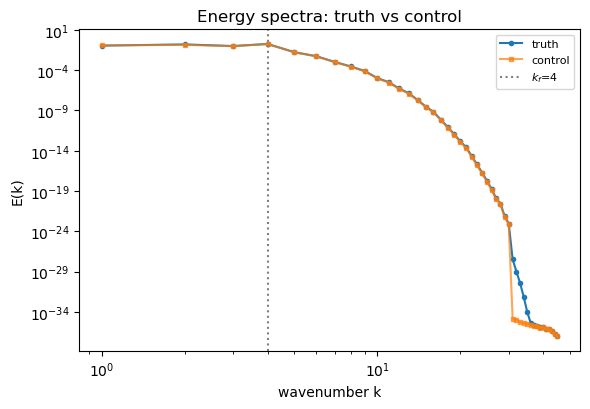

In [12]:
k_t, E_t = kinetic_energy_spectrum(truth)
k_c, E_c = kinetic_energy_spectrum(control)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.loglog(k_t, E_t, "o-", ms=3, label="truth")
ax.loglog(k_c, E_c, "s-", ms=3, label="control", alpha=0.7)
ax.axvline(PARAMS["k_f"], color="gray", ls=":", label=f"$k_f$={PARAMS['k_f']}")
ax.set_xlabel("wavenumber k"); ax.set_ylabel("E(k)")
ax.set_title("Energy spectra: truth vs control"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Independent test set (for notebook 05)

An **independent** trajectory (different seed from the training run) with **1200 assimilation cycles**, saved with a `_test` suffix. Notebook 05 uses this so the ML methods are evaluated on data unseen during training.

In [13]:
TEST_CYCLES = 1200

mt = QG2D(**PARAMS)
qh = np.fft.fft2(mt.random_ic(seed=seed + 999, amp=2.0))
for _ in range(int(round(SPINUP_OBS / dt))):        # independent spin-up
    qh = mt.step(qh, dt)
q_spin = np.real(np.fft.ifft2(qh)); clim_t = q_spin.std()
delta = mt.random_ic(seed=seed + 1000, amp=1.0); delta *= PERT_FRAC * clim_t / delta.std()
win = TEST_CYCLES * OBS_EVERY * dt

control_test = mt.run(q_spin,         tf=win, dt=dt, spinup=0.0,
                      store_every=OBS_EVERY, path="da_data/control_test.nc")
truth_test   = mt.run(q_spin + delta, tf=win, dt=dt, spinup=0.0,
                      store_every=OBS_EVERY, path="da_data/truth_test.nc")

t_t = truth_test["time"].values
sig_t = NOISE_FRAC * float(truth_test["q"].std())
rng_t = np.random.default_rng(seed + 7); Nt = PARAMS["N"]
for frac, path in [(1.0, "da_data/obs_full_test.nc"),
                   (SPARSE_FRAC, "da_data/obs_sparse_test.nc")]:
    mask = np.zeros(Nt * Nt, bool)
    if frac >= 1:
        mask[:] = True
    else:
        mask[rng_t.choice(Nt * Nt, int(round(frac * Nt * Nt)), replace=False)] = True
    mask = mask.reshape(Nt, Nt)
    o = np.where(mask[None], truth_test["q"].values + rng_t.normal(0, sig_t, truth_test["q"].shape), np.nan)
    _save_netcdf(xr.Dataset({"obs": (("time","y","x"), o), "mask": (("y","x"), mask.astype("i1"))},
                 coords={"time": t_t, "y": truth_test["y"].values, "x": truth_test["x"].values},
                 attrs={**PARAMS, "sigma_obs": sig_t, "dt_obs": OBS_EVERY * dt,
                        "coverage": float(mask.mean())}), path)

print(f"saved test set ({truth_test.sizes['time']} cycles): "
      "truth_test, control_test, obs_full_test, obs_sparse_test")

saved test set (1201 cycles): truth_test, control_test, obs_full_test, obs_sparse_test


## Stored files & next steps

Under `da_data/`: `doubling_time.npz` (calibration), `control.nc`, `truth.nc`,
`obs_full.nc`, `obs_sparse.nc`. Each observation file records `sigma_obs`,
`dt_obs`, `coverage`, and the measured `tau2_mtu` / `mtu_per_day`.

**Next:** run an EnKF from the control initial state, assimilating
`obs_full` / `obs_sparse` every `dt_obs`, and compare the analysis RMSE against
this free-running divergence as the baseline to beat. To enlarge the training
set, raise `N_CYCLES` and delete the cached `.nc` files to recompute.